In [ ]:
# Install necessary libraries
!pip install pandas scikit-learn shap seaborn matplotlib xgboost --quiet

In [ ]:
!pip install fpdf gradio

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetic_data.csv to diabetic_data.csv
Saving IDS_mapping.csv to IDS_mapping.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

import joblib

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,StackingClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score,roc_curve, average_precision_score,precision_recall_curve
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder



In [ ]:
df = pd.read_csv('diabetic_data.csv')
ids = pd.read_csv("IDS_mapping.csv", header=None, names=["id", "description"])
ids.head(20)


,id,description
0,admission_type_id,description
1,1,Emergency
2,2,Urgent
3,3,Elective
4,4,Newborn
5,5,Not Available
6,6,NaN
7,7,Trauma Center
8,8,Not Mapped
9,NaN,NaN


In [ ]:
import pandas as pd

# Load the full IDS file
ids = pd.read_csv("IDS_mapping.csv", names=["id", "description"])

# --- Slice each part based on inspection ---

# 1. Admission Type: rows 1 to 8 (skip header at 0)
admission_type_df = ids.iloc[1:9].copy()
admission_type_df.columns = ["admission_type_id", "admission_type_desc"]

# 2. Discharge Disposition: rows 11 to 40 (skip header at 10)
discharge_df = ids.iloc[11:41].copy()
discharge_df.columns = ["discharge_disposition_id", "discharge_desc"]

# 3. Admission Source: rows 43 to 67 (skip header at 42)
admission_source_df = ids.iloc[43:68].copy()
admission_source_df.columns = ["admission_source_id", "admission_source_desc"]

# --- Convert ID columns to numeric ---
admission_type_df["admission_type_id"] = pd.to_numeric(admission_type_df["admission_type_id"])
discharge_df["discharge_disposition_id"] = pd.to_numeric(discharge_df["discharge_disposition_id"])
admission_source_df["admission_source_id"] = pd.to_numeric(admission_source_df["admission_source_id"])

# Optional: check a preview
print(admission_type_df.head())
print(discharge_df.head())
print(admission_source_df.head())


   admission_type_id admission_type_desc
1                  1           Emergency
2                  2              Urgent
3                  3            Elective
4                  4             Newborn
5                  5       Not Available
    discharge_disposition_id  \
11                         1   
12                         2   
13                         3   
14                         4   
15                         5   

                                       discharge_desc  
11                                 Discharged to home  
12  Discharged/transferred to another short term h...  
13                      Discharged/transferred to SNF  
14                      Discharged/transferred to ICF  
15  Discharged/transferred to another type of inpa...  
    admission_source_id                            admission_source_desc
43                    1                               Physician Referral
44                    2                                  Clinic Referral
45    

In [ ]:
admission_type_df.to_csv("admission_type_mapping.csv", index=False)
discharge_df.to_csv("discharge_mapping.csv", index=False)
admission_source_df.to_csv("admission_source_mapping.csv", index=False)


In [ ]:

# 1. Load the full dataset
df = pd.read_csv('diabetic_data.csv')

# 2. Load mapping files
admission_type_df = pd.read_csv("admission_type_mapping.csv")
discharge_df = pd.read_csv("discharge_mapping.csv")
admission_source_df = pd.read_csv("admission_source_mapping.csv")

# 3. Merge mappings into main dataframe
df = df.merge(admission_type_df, how='left', on='admission_type_id')
df = df.merge(discharge_df, how='left', on='discharge_disposition_id')
df = df.merge(admission_source_df, how='left', on='admission_source_id')

df.drop(columns=["admission_type_id", "discharge_disposition_id", "admission_source_id"], inplace=True)

# 4. Filter "<30" and "NO"
df = df[df["readmitted"].isin(["<30", "NO"])].reset_index(drop=True)

# 5. Binary target
df["readmitted_30"] = df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)

# 6. Drop unused or uninformative columns
df.drop(["encounter_id", "patient_nbr", "weight", "payer_code", "medical_specialty",
         "readmitted", "diag_1", "diag_2", "diag_3"], axis=1, inplace=True)



In [ ]:
# 7. Handle missing values
df.replace("?", np.nan, inplace=True)

# Drop columns with >50% missing values
missing_ratio = df.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.5].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)

# Impute remaining missing categorical values with most frequent
cat_cols = df.select_dtypes(include='object').columns
imp_cat = SimpleImputer(strategy="most_frequent")
df[cat_cols] = imp_cat.fit_transform(df[cat_cols])

In [ ]:
# Feature engineering
# 1. Age Group: convert "[70-80)" → 75
df['age'] = df['age'].apply(lambda x: int(x.strip('[]').split('-')[0]) + 5)

# 2. High-risk flags
df['high_inpatient_visits'] = (df['number_inpatient'] >= 2).astype(int)
df['frequent_emergency'] = (df['number_emergency'] >= 1).astype(int)

# 3. Combined burden scores
df['medication_burden'] = df['num_medications'] * df['number_diagnoses']
df['inpatient_timespan'] = df['number_inpatient'] * df['time_in_hospital']
df['total_visits'] = df['number_inpatient'] + df['number_emergency'] + df['number_outpatient']
df['visit_density'] = df['total_visits'] / (df['time_in_hospital'] + 1)

# 4. Simplify discharge categories
def simplify_discharge(desc):
    if "Home" in desc:
        return "home"
    elif "Skilled Nursing" in desc or "Rehab" in desc or "Hospice" in desc:
        return "care"
    elif "Expired" in desc:
        return "expired"
    else:
        return "other"

df['discharge_group'] = df['discharge_desc'].apply(simplify_discharge)


In [ ]:
 #Recalculate categorical columns
cat_cols = df.select_dtypes(include='object').columns

# 8. Encode categorical columns
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# Save encoders
joblib.dump(encoders, "label_encoders.pkl")

# 9. Train-test split
X = df.drop("readmitted_30", axis=1)
y = df["readmitted_30"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 10. Dataset summary
print(f"✅ Total samples: {len(df)}")
print(f"📊 Train samples: {len(X_train)}")
print(f"🧪 Test samples: {len(X_test)}")
print(f"Class distribution:\n{y.value_counts()}")

✅ Total samples: 66221
📊 Train samples: 46354
🧪 Test samples: 19867
Class distribution:
readmitted_30
0    54864
1    11357
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[16235   225]
 [ 3068   339]]
              precision    recall  f1-score   support

           0       0.84      0.99      0.91     16460
           1       0.60      0.10      0.17      3407

    accuracy                           0.83     19867
   macro avg       0.72      0.54      0.54     19867
weighted avg       0.80      0.83      0.78     19867



In [ ]:
print(df["readmitted_30"].value_counts(normalize=True))


readmitted_30
0    0.828499
1    0.171501
Name: proportion, dtype: float64


In [ ]:
pip install imbalanced-learn


In [ ]:

# Set k_neighbors to a smaller value
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)



In [ ]:
# Train Random Forest on resampled data
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# Predict on test set
y_pred = rf_model.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[15471   989]
 [ 2687   720]]
              precision    recall  f1-score   support

           0       0.85      0.94      0.89     16460
           1       0.42      0.21      0.28      3407

    accuracy                           0.81     19867
   macro avg       0.64      0.58      0.59     19867
weighted avg       0.78      0.81      0.79     19867



In [ ]:
import xgboost as xgb
# Automatically compute scale_pos_weight-if not using SMOTE
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,  # Auto if unsure
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))


[[11647  4813]
 [ 1276  2131]]
              precision    recall  f1-score   support

           0       0.90      0.71      0.79     16460
           1       0.31      0.63      0.41      3407

    accuracy                           0.69     19867
   macro avg       0.60      0.67      0.60     19867
weighted avg       0.80      0.69      0.73     19867

ROC AUC Score: 0.7309233527142497


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(xgb_model, X, y, cv=skf, scoring='roc_auc')

print("Average ROC AUC from CV:", np.mean(auc_scores))


Average ROC AUC from CV: 0.7263768008755204


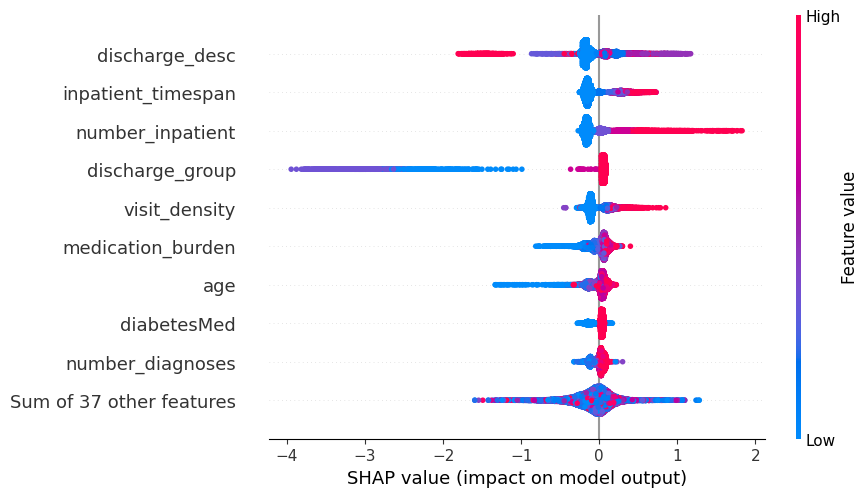

In [ ]:
import shap
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)


In [ ]:
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier

xgb = XGBClassifier()
selector = RFE(xgb, n_features_to_select=10)
selector = selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.support_]
print("Top features:", list(selected_features))


Top features: ['number_inpatient', 'number_diagnoses', 'metformin', 'diabetesMed', 'discharge_desc', 'admission_source_desc', 'inpatient_timespan', 'total_visits', 'visit_density', 'discharge_group']


In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Automatically compute scale_pos_weight if not using SMOTE
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# Define the parameter grid for grid search
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [scale_pos_weight],  # Use computed scale_pos_weight
    'eval_metric': ['auc'],  # AUC metric for evaluation
    'use_label_encoder': [False],
}

# Set up the model
xgb_model = XGBClassifier(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    xgb_model, param_grid=param_grid,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)

# Train the model with GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best model
best_model1 = grid_search.best_estimator_

# Make predictions using the best model
y_pred = best_model1.predict(X_test)
y_prob = best_model1.predict_proba(X_test)[:, 1]

# Print results
print("Best Params:", grid_search.best_params_)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))


Fitting 5 folds for each of 256 candidates, totalling 1280 fits
Best Params: {'colsample_bytree': 0.8, 'eval_metric': 'auc', 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': np.float64(4.830691823899371), 'subsample': 0.8, 'use_label_encoder': False}
[[11517  4943]
 [ 1234  2173]]
              precision    recall  f1-score   support

           0       0.90      0.70      0.79     16460
           1       0.31      0.64      0.41      3407

    accuracy                           0.69     19867
   macro avg       0.60      0.67      0.60     19867
weighted avg       0.80      0.69      0.72     19867

ROC AUC Score: 0.7303639565600234


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Automatically compute scale_pos_weight if not using SMOTE
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# Define the parameter grid for randomized search
param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [scale_pos_weight],  # Use computed scale_pos_weight
    'eval_metric': ['auc'],  # AUC metric for evaluation
    'use_label_encoder': [False],
}

# Set up the model
xgb_model = XGBClassifier(random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    xgb_model, param_distributions=param_dist,
    n_iter=50, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)

# Train the model with RandomizedSearchCV
random_search.fit(X_train, y_train)

# Get the best model
best_model = random_search.best_estimator_

# Make predictions using the best model
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Print results
print("Best Params:", random_search.best_params_)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'use_label_encoder': False, 'subsample': 0.8, 'scale_pos_weight': np.float64(4.830691823899371), 'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.1, 'eval_metric': 'auc', 'colsample_bytree': 1.0}
[[11451  5009]
 [ 1227  2180]]
              precision    recall  f1-score   support

           0       0.90      0.70      0.79     16460
           1       0.30      0.64      0.41      3407

    accuracy                           0.69     19867
   macro avg       0.60      0.67      0.60     19867
weighted avg       0.80      0.69      0.72     19867

ROC AUC Score: 0.7315979876324956


In [ ]:
 #Use best hyperparameters from earlier GridSearchCV
best_params = {
    'colsample_bytree': 0.8,
    'eval_metric': 'auc',
    'learning_rate': 0.01,
    'max_depth': 7,
    'n_estimators': 200,
    'scale_pos_weight': 4.830691823899371,  # Replace with float(y_train.value_counts()[0] / y_train.value_counts()[1]) if dynamic
    'subsample': 0.8,
    'use_label_encoder': False
}

# Train the best model
best_model_final = XGBClassifier(**best_params, random_state=42)
best_model_final.fit(X_train, y_train)

# Save the model
joblib.dump(best_model_final, "best_xgb_model_gridsearch.pkl")

# Predict
y_pred = best_model_final.predict(X_test)
y_prob = best_model_final.predict_proba(X_test)[:, 1]

# Evaluation
print("📄 Classification Report:\n")
print(classification_report(y_test, y_pred))
print("🔍 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"📊 ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

📄 Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.70      0.79     16460
           1       0.31      0.64      0.41      3407

    accuracy                           0.69     19867
   macro avg       0.60      0.67      0.60     19867
weighted avg       0.80      0.69      0.72     19867

🔍 Confusion Matrix:
[[11517  4943]
 [ 1234  2173]]
📊 ROC AUC Score: 0.7304


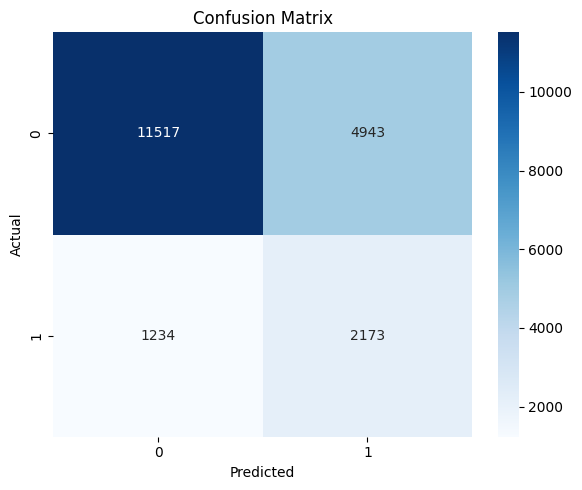

In [ ]:
# Ensure predictions and probabilities
y_pred = best_model_final.predict(X_test)
y_proba = best_model_final.predict_proba(X_test)[:, 1]  # for ROC and PR curves

# ------------------- Confusion Matrix -------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

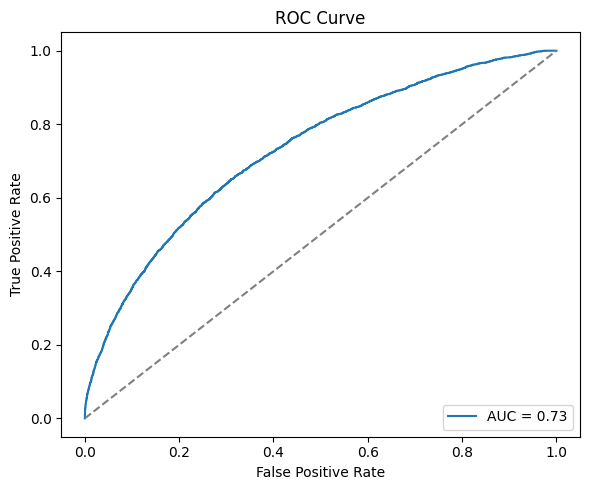

In [ ]:
# ------------------- ROC Curve -------------------
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png")
plt.show()


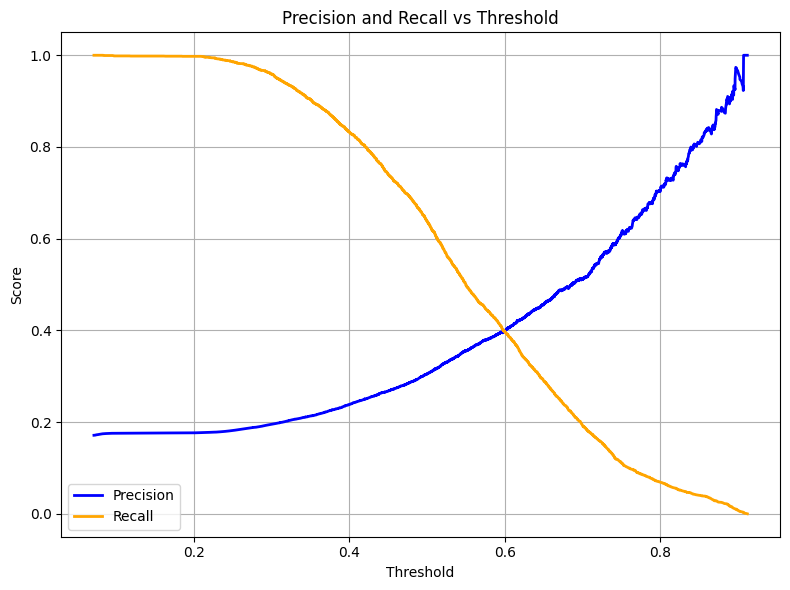

In [ ]:
# ------------------- Precision and Recall vs Threshold -------------------
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label="Precision", color="blue", linewidth=2)
plt.plot(thresholds, recall[:-1], label="Recall", color="orange", linewidth=2)
plt.title("Precision and Recall vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig("precision_recall_threshold.png")
plt.show()


100%|===================| 19866/19867 [04:34<00:00]       

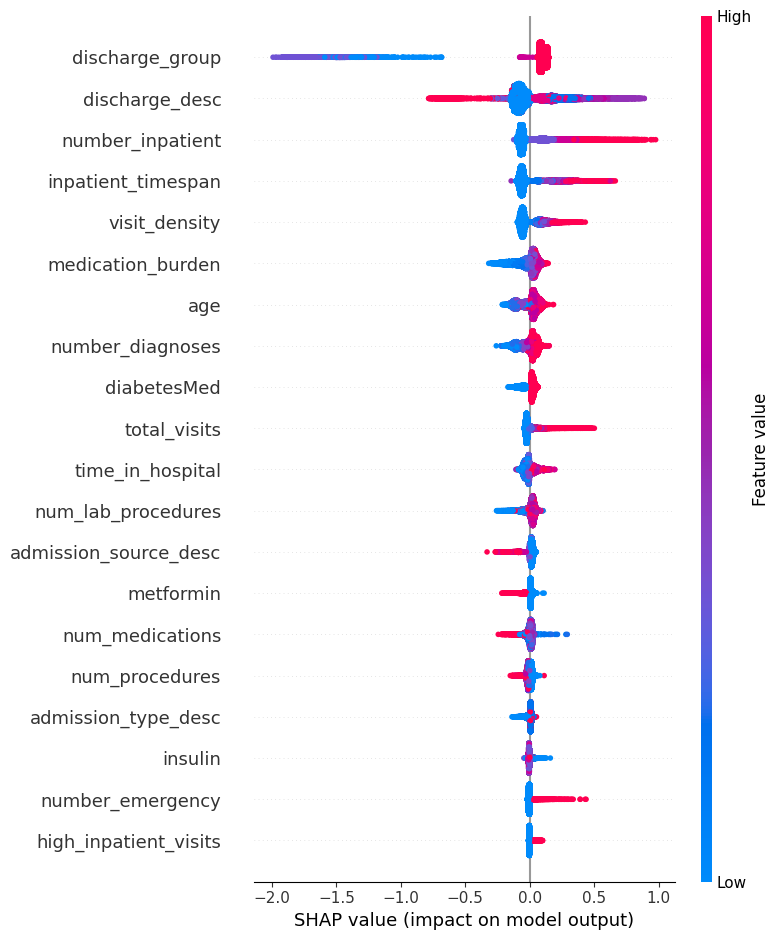

In [ ]:
import shap

# Use TreeExplainer for XGBoost
explainer = shap.Explainer(best_model_final, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png")
plt.show()



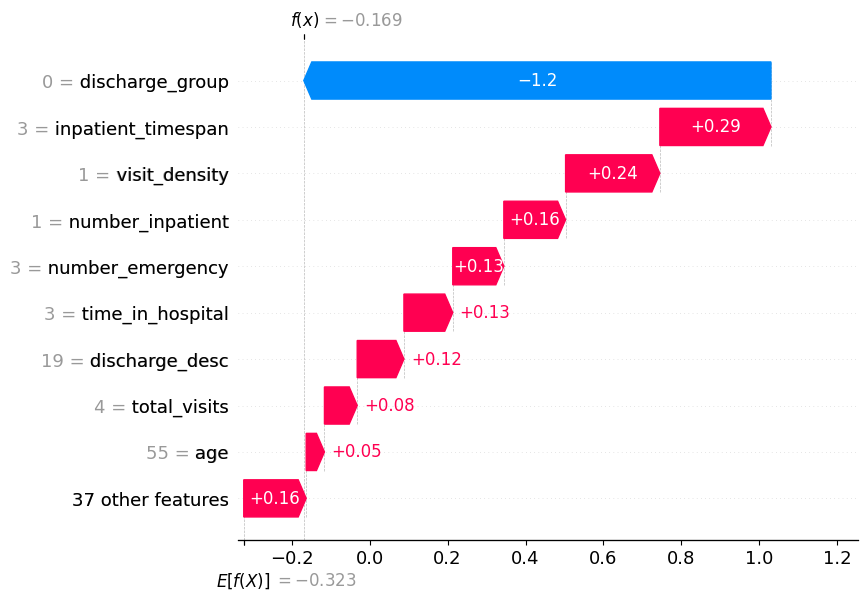

In [ ]:
shap.plots.waterfall(shap_values[0])


In [ ]:
risk_scores = best_model_final.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy['readmitted'] = y_test.values
X_test_copy['risk_score'] = risk_scores

# High risk patients
high_risk = X_test_copy[X_test_copy['risk_score'] > 0.8]
high_risk.head()


,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,admission_source_desc,high_inpatient_visits,frequent_emergency,medication_burden,inpatient_timespan,total_visits,visit_density,discharge_group,readmitted,risk_score
28741,0,0,35,3,85,3,15,3,3,7,...,1,1,1,135,21,13,3.250000,3,1,0.877755
7254,2,1,65,5,50,1,29,0,0,6,...,12,1,0,174,30,6,1.000000,3,0,0.828873
39697,2,0,55,5,47,0,11,3,0,5,...,5,1,0,99,25,8,1.333333,3,1,0.863451
48359,2,1,75,4,39,2,18,0,5,11,...,5,1,1,162,44,16,3.200000,3,1,0.898108
54036,2,1,65,2,50,1,13,0,5,3,...,5,1,1,117,6,8,2.666667,3,0,0.802709


Text(0.5, 1.0, 'Inpatient Admissions of High Risk Patients')

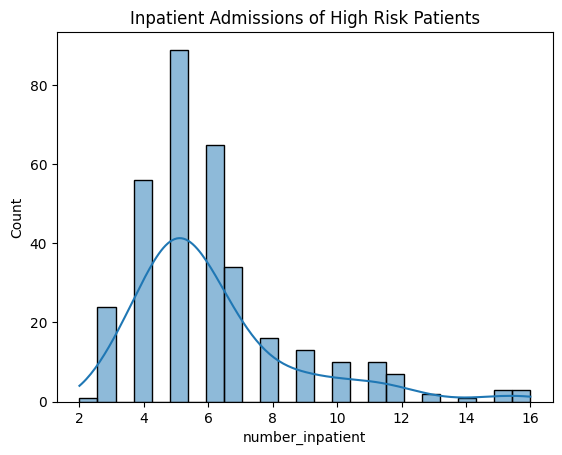

In [ ]:
#Minimal Viable Experiment (MVE)
#Hypothesis: “High-risk patients have more prior admissions and comorbidities.”

sns.histplot(data=high_risk, x='number_inpatient', kde=True)
plt.title('Inpatient Admissions of High Risk Patients')


In [ ]:
from sklearn.metrics import roc_auc_score

# AUC of the model on the test set-risk prediction
auc = roc_auc_score(y_test, risk_scores)
print(f"Model AUC: {auc:.4f}")


Model AUC: 0.7304


In [ ]:
from sklearn.metrics import precision_score

# Sort by risk score in descending order and select the top 20%
top_20_percent = X_test_copy.sort_values(by='risk_score', ascending=False).iloc[:int(len(X_test_copy)*0.2)]

# Calculate Precision@Top20%
precision_top_20 = precision_score(top_20_percent['readmitted'], (top_20_percent['risk_score'] > 0.5).astype(int))  # Assuming threshold = 0.5 for readmission
print(f"Precision@Top 20% Risk Scores: {precision_top_20:.4f}")


Precision@Top 20% Risk Scores: 0.3808


In [ ]:
# Calculate percentage flagged correctly (i.e., readmitted patients in high-risk group)
correctly_flagged = high_risk[high_risk['readmitted'] == 1].shape[0] / high_risk.shape[0]
print(f"% Flagged Correctly: {correctly_flagged:.2%}")


% Flagged Correctly: 70.36%


In [ ]:
# Simulate 10% reduction by randomly flagging 10% fewer high-risk readmitted patients
import numpy as np

# Simulate a 10% reduction in readmissions for high-risk patients
reduced_high_risk = high_risk.copy()
reduced_readmitted = reduced_high_risk[reduced_high_risk['readmitted'] == 1]
num_to_retain = int(reduced_readmitted.shape[0] * 0.9)  # 10% reduction

# Randomly drop 10% of readmitted patients
reduced_readmitted = reduced_readmitted.sample(n=num_to_retain, random_state=42)

# Combine with non-readmitted high-risk patients
reduced_high_risk = pd.concat([reduced_readmitted, reduced_high_risk[reduced_high_risk['readmitted'] == 0]])

# Check the new number of readmitted high-risk patients
reduced_high_risk['readmitted'].sum(), high_risk['readmitted'].sum()


(np.int64(211), np.int64(235))

The output (np.int64(211), np.int64(235)) indicates that after simulating a 10% reduction in readmissions for high-risk patients, the number of readmitted high-risk patients has decreased from 235 to 211.

This represents a 10% reduction in the number of readmissions among high-risk patients as intended.

In [ ]:
# Recalculate Precision@Top20% for the reduced high-risk group
top_20_percent_reduced = reduced_high_risk.sort_values(by='risk_score', ascending=False).iloc[:int(len(reduced_high_risk)*0.2)]
precision_top_20_reduced = precision_score(top_20_percent_reduced['readmitted'], (top_20_percent_reduced['risk_score'] > 0.5).astype(int))
print(f"Precision@Top 20% Risk Scores (After 10% Reduction): {precision_top_20_reduced:.4f}")


Precision@Top 20% Risk Scores (After 10% Reduction): 0.8871


In [ ]:
correctly_flagged_reduced = reduced_high_risk[reduced_high_risk['readmitted'] == 1].shape[0] / reduced_high_risk.shape[0]
print(f"% Flagged Correctly (After 10% Reduction): {correctly_flagged_reduced:.2%}")


% Flagged Correctly (After 10% Reduction): 68.06%


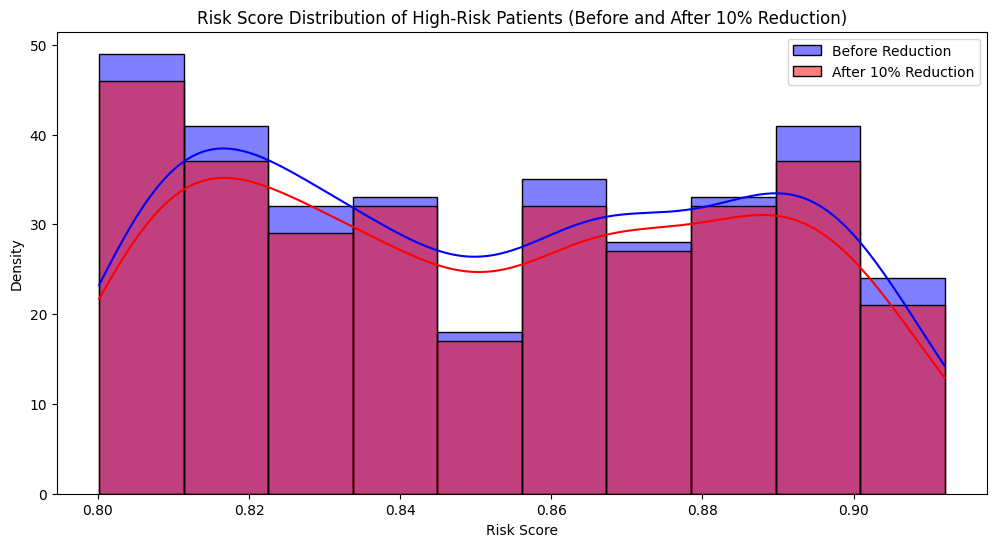

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot risk score distribution before and after reduction
plt.figure(figsize=(12, 6))

sns.histplot(high_risk['risk_score'], kde=True, label='Before Reduction', color='blue')
sns.histplot(reduced_high_risk['risk_score'], kde=True, label='After 10% Reduction', color='red')

plt.title('Risk Score Distribution of High-Risk Patients (Before and After 10% Reduction)')
plt.xlabel('Risk Score')
plt.ylabel('Density')
plt.legend()
plt.show()


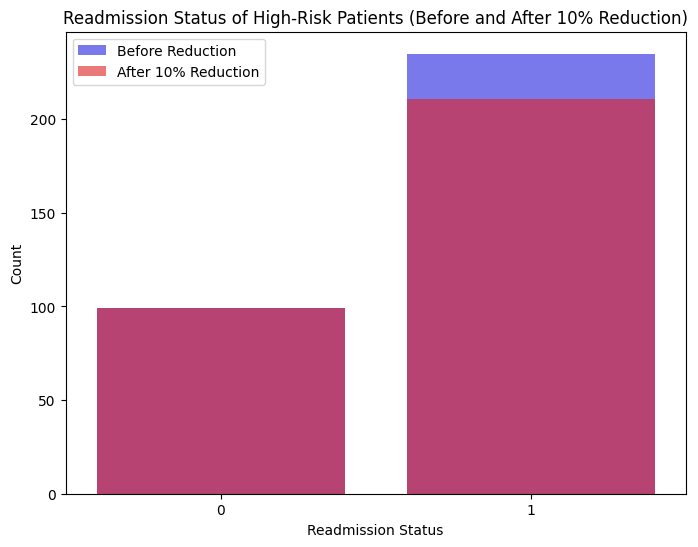

In [ ]:
# Plot the count of readmitted vs non-readmitted patients before and after reduction
readmitted_before = high_risk['readmitted'].value_counts()
readmitted_after = reduced_high_risk['readmitted'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=readmitted_before.index, y=readmitted_before.values, label='Before Reduction', color='blue', alpha=0.6)
sns.barplot(x=readmitted_after.index, y=readmitted_after.values, label='After 10% Reduction', color='red', alpha=0.6)

plt.title('Readmission Status of High-Risk Patients (Before and After 10% Reduction)')
plt.xlabel('Readmission Status')
plt.ylabel('Count')
plt.legend()
plt.show()


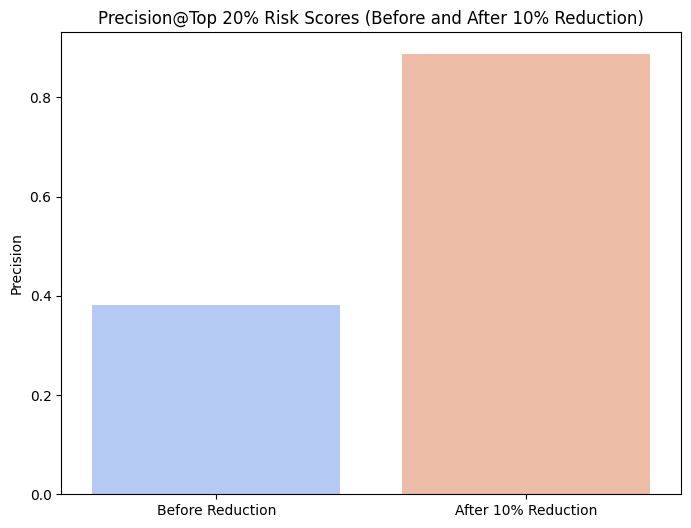

In [ ]:
# Plot Precision@Top 20% before and after reduction
precision_data = {
    'Before Reduction': precision_top_20,
    'After 10% Reduction': precision_top_20_reduced
}

plt.figure(figsize=(8, 6))
sns.barplot(x=list(precision_data.keys()), y=list(precision_data.values()), palette='coolwarm')

plt.title('Precision@Top 20% Risk Scores (Before and After 10% Reduction)')
plt.ylabel('Precision')
plt.show()


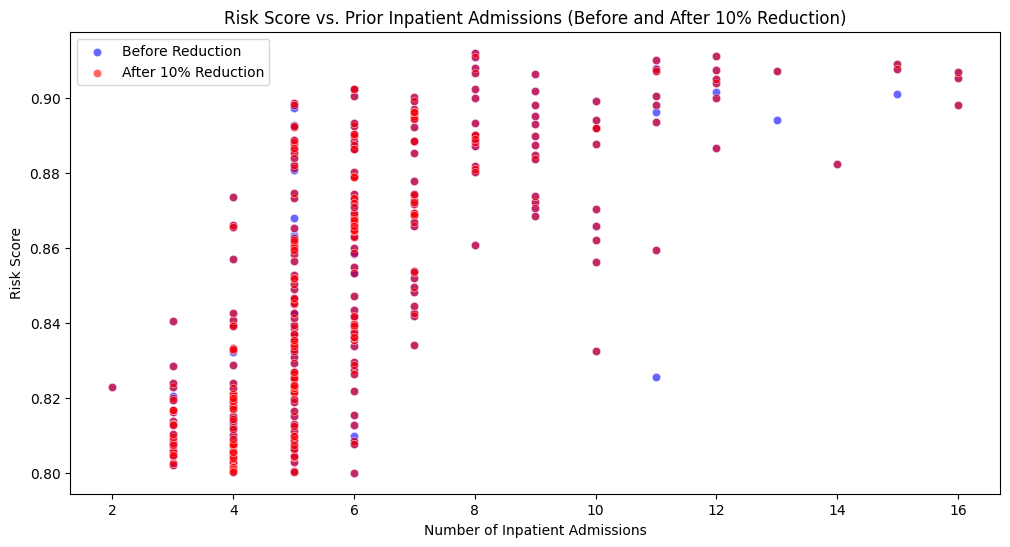

In [ ]:
# Plot risk score vs. prior inpatient admissions before and after reduction
plt.figure(figsize=(12, 6))

sns.scatterplot(data=high_risk, x='number_inpatient', y='risk_score', color='blue', alpha=0.6, label='Before Reduction')
sns.scatterplot(data=reduced_high_risk, x='number_inpatient', y='risk_score', color='red', alpha=0.6, label='After 10% Reduction')

plt.title('Risk Score vs. Prior Inpatient Admissions (Before and After 10% Reduction)')
plt.xlabel('Number of Inpatient Admissions')
plt.ylabel('Risk Score')
plt.legend()
plt.show()


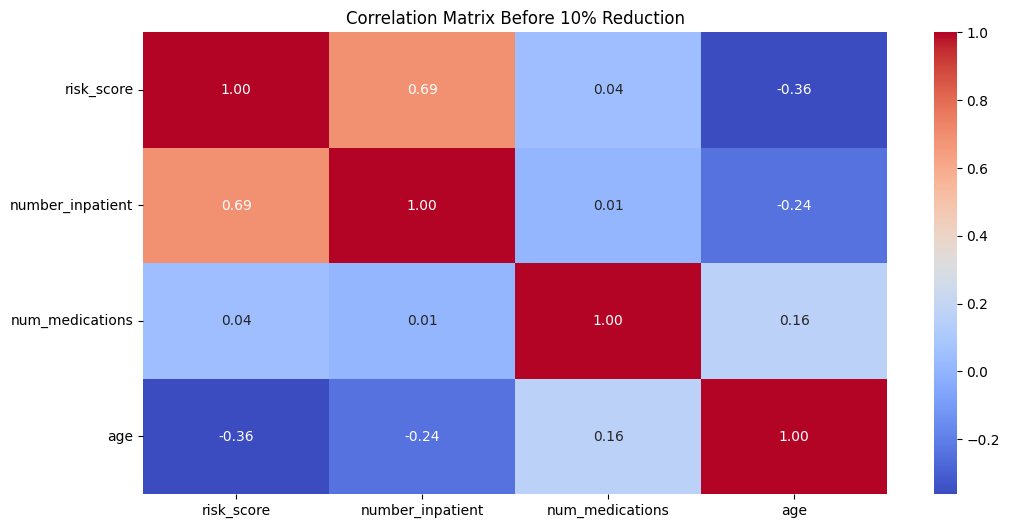

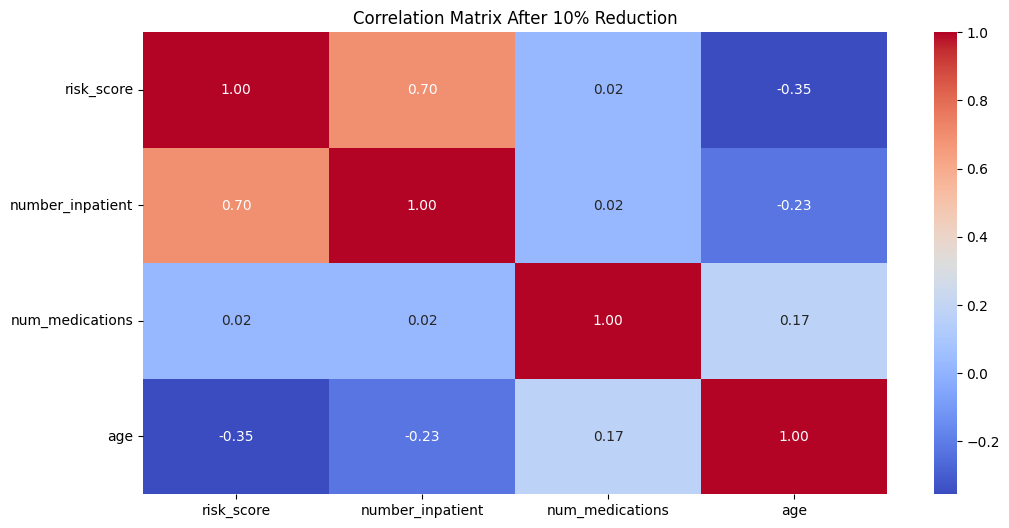

In [ ]:
# Plot the correlation matrix for features before and after reduction
corr_before = high_risk[['risk_score', 'number_inpatient', 'num_medications', 'age']].corr()
corr_after = reduced_high_risk[['risk_score', 'number_inpatient', 'num_medications', 'age']].corr()

plt.figure(figsize=(12, 6))
sns.heatmap(corr_before, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix Before 10% Reduction')
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(corr_after, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix After 10% Reduction')
plt.show()


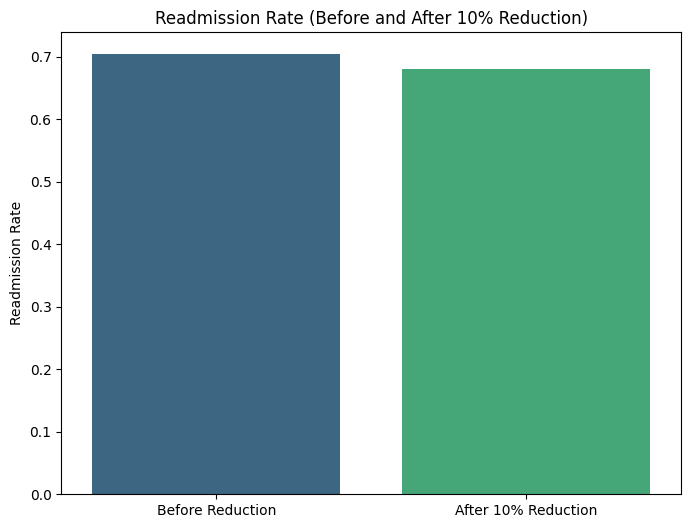

In [ ]:
# Calculate readmission rates before and after reduction
readmission_rate_before = high_risk['readmitted'].mean()
readmission_rate_after = reduced_high_risk['readmitted'].mean()

# Plot the comparison of readmission rates
plt.figure(figsize=(8, 6))
sns.barplot(x=['Before Reduction', 'After 10% Reduction'], y=[readmission_rate_before, readmission_rate_after], palette='viridis')

plt.title('Readmission Rate (Before and After 10% Reduction)')
plt.ylabel('Readmission Rate')
plt.show()


In [ ]:
import joblib

# Extract feature columns from X_train since SMOTE does not alter the structure of the data
feature_columns = X_train.columns.tolist()

# Save feature columns to a .pkl file for later use during prediction
joblib.dump(feature_columns, "feature_columns.pkl")
print("✅ feature_columns.pkl saved!")


✅ feature_columns.pkl saved!


In [ ]:
import pandas as pd
import random

# Define possible values for each categorical column
races = ['Caucasian', 'AfricanAmerican', 'Hispanic', 'Asian', 'Other']
genders = ['Male', 'Female']
ages = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
med_states = ['No', 'Steady', 'Up', 'Down']
test_results = ['None', 'Norm', '>200', '>300']
yes_no = ['Yes', 'No']
change_opts = ['Ch', 'No']
admission_types = ['Emergency', 'Urgent', 'Elective', 'Newborn']
discharge_descs = ['Discharged to home', 'Discharged to rehab', 'Left AMA', 'Expired', 'Hospice', 'Skilled Nursing']
admission_sources = ['Emergency Room', 'Referral', 'Clinic']

# Define a range for comorbidities (0 to 4)
max_comorbidities = 4

# Create synthetic data for 20 patients
data = []
for i in range(20):
    row = [
        random.choice(races),
        random.choice(genders),
        random.choice(ages),
        random.randint(1, 14),  # time_in_hospital
        random.randint(1, 100),  # num_lab_procedures
        random.randint(0, 6),  # num_procedures
        random.randint(1, 50),  # num_medications
        random.randint(0, 10),  # number_outpatient
        random.randint(0, 5),   # number_emergency
        random.randint(0, 10),  # number_inpatient
        random.randint(1, 16),  # number_diagnoses
        random.choice(test_results),  # max_glu_serum
        random.choice(test_results),  # A1Cresult
    ]
    # Add 23 drug-related features
    row += [random.choice(med_states) for _ in range(23)]
    # Add change, diabetesMed, admission_type_desc, discharge_desc, admission_source_desc
    row += [
        random.choice(change_opts),
        random.choice(yes_no),
        random.choice(admission_types),
        random.choice(discharge_descs),
        random.choice(admission_sources)
    ]
    # Add comorbidities (random number between 0 and 4)
    row.append(random.randint(0, max_comorbidities))

    data.append(row)

# Define column names including comorbidities
columns = [
    'race', 'gender', 'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses',
    'max_glu_serum', 'A1Cresult',
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
    'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
    'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone',
    'change', 'diabetesMed', 'admission_type_desc', 'discharge_desc', 'admission_source_desc',
    'comorbidities'
]

# Create DataFrame and save
df = pd.DataFrame(data, columns=columns)
csv_path = "sample_20_patients_readmission_with_comorbidities.csv"
df.to_csv(csv_path, index=False)

print(f"✅ Synthetic dataset generated and saved as: {csv_path}")


✅ Synthetic dataset generated and saved as: sample_20_patients_readmission_with_comorbidities.csv


In [ ]:
# app.py
%%writefile app.py
import gradio as gr
import pandas as pd
import numpy as np
import joblib
import zipfile
import os
from fpdf import FPDF

# Load model and helpers
model = joblib.load("best_xgb_model_gridsearch.pkl")
feature_columns = joblib.load("feature_columns.pkl")
encoders = joblib.load("label_encoders.pkl")

# Feature engineering steps
def engineer_features(df):
    # 1. Age range to median value
    df['age'] = df['age'].apply(lambda x: int(x.strip('[]').split('-')[0]) + 5 if isinstance(x, str) else x)

    # 2. High-risk flags
    df['high_inpatient_visits'] = (df['number_inpatient'] >= 2).astype(int)
    df['frequent_emergency'] = (df['number_emergency'] >= 1).astype(int)

    # 3. Combined scores
    df['medication_burden'] = df['num_medications'] * df['number_diagnoses']
    df['inpatient_timespan'] = df['number_inpatient'] * df['time_in_hospital']
    df['total_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
    df['visit_density'] = df['total_visits'] / (df['time_in_hospital'] + 1)

    # 4. Simplify discharge_desc
    def simplify_discharge(desc):
        if "Home" in desc:
            return "home"
        elif "Skilled Nursing" in desc or "Rehab" in desc or "Hospice" in desc:
            return "care"
        elif "Expired" in desc:
            return "expired"
        else:
            return "other"
    df['discharge_group'] = df['discharge_desc'].apply(simplify_discharge)

    return df

# Apply saved label encoders
def apply_label_encoders(df, encoders):
    for col, le in encoders.items():
        if col in df.columns:
            df[col] = df[col].fillna("Unknown").astype(str)
            known_classes = set(le.classes_)
            df[col] = df[col].apply(lambda x: x if x in known_classes else "Unknown")
            if "Unknown" not in le.classes_:
                le.classes_ = np.append(le.classes_, "Unknown")
            df[col] = le.transform(df[col])
    return df

# Generate individual report
def generate_report(patient_id, prediction, features):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=12)
    pdf.cell(200, 10, txt="Patient Readmission Risk Report", ln=True, align='C')
    pdf.ln(10)
    pdf.cell(200, 10, txt=f"Patient ID: {patient_id}", ln=True)
    pdf.cell(200, 10, txt=f"Prediction: {'Likely Readmitted' if prediction == 1 else 'Low Risk'}", ln=True)
    pdf.ln(10)
    pdf.cell(200, 10, txt="Patient Details:", ln=True)
    for key, value in features.items():
        pdf.cell(200, 10, txt=f"{key.replace('_', ' ').title()}: {value}", ln=True)
    path = f"patient_{patient_id}_report.pdf"
    pdf.output(path)
    return path

# Prediction logic
def predict_readmission(file):
    try:
        df = pd.read_csv(file.name)

        # Feature engineering
        df = engineer_features(df)

        # Encode categories
        df = apply_label_encoders(df, encoders)

        # Ensure all required columns exist
        missing_cols = [col for col in feature_columns if col not in df.columns]
        if missing_cols:
            return f"❌ Missing required columns: {missing_cols}", None, None

        # Final prediction
        preds = model.predict(df[feature_columns])
        df["readmission_prediction"] = preds

        # Generate PDFs
        pdf_paths = []
        for i, row in df.iterrows():
            patient_id = i + 1
            features = {
                "age": row.get("age"),
                "time_in_hospital": row.get("time_in_hospital"),
                "number_diagnoses": row.get("number_diagnoses"),
                "num_medications": row.get("num_medications"),
                "comorbidities": row.get("comorbidities"),
                "medication_burden": row.get("medication_burden")
            }
            pdf_path = generate_report(patient_id, row["readmission_prediction"], features)
            pdf_paths.append(pdf_path)

        # ZIP all reports
        zip_path = "all_patient_reports.zip"
        with zipfile.ZipFile(zip_path, "w") as zipf:
            for path in pdf_paths:
                zipf.write(path, os.path.basename(path))
                os.remove(path)

        summary = f"✅ Predicted {sum(preds)} of {len(preds)} patients likely to be readmitted."
        return summary, df[["readmission_prediction"]], zip_path

    except Exception as e:
        return f"❌ Error: {str(e)}", None, None

# Gradio Interface
iface = gr.Interface(
    fn=predict_readmission,
    inputs=gr.File(label="📁 Upload Patient CSV File"),
    outputs=[
        gr.Textbox(label="📊 Prediction Summary"),
        gr.Dataframe(label="📋 Predictions", type="pandas"),
        gr.File(label="📥 Download All Reports (.zip)")
    ],
    title="🏥 Patient Readmission Risk Predictor",
    description="Upload a CSV file with patient records to predict 30-day readmission risk and download personalized PDF reports."
)

iface.launch()
